# Tx progression over time for CD8+ and CD4+ PAGA cluster

https://support.bioconductor.org/p/p133524/

In [1]:
library_load <- suppressMessages(
    
    suppressWarnings(
    
            list(
                
                # Seurat 
                library(Seurat), 
                
                # RNA seq
                library(edgeR), 

                # Data 
                library(tidyverse), 
                library(openxlsx), 

                # Plotting 
                library(ComplexHeatmap), 
                library(circlize), 
                library(viridis), 
                library(ggplotify), 
                library(patchwork), 
                library(RColorBrewer), 

                # Python 
                library(reticulate)
            
            )
    )
)

In [2]:
# Configure reticulate 
use_condaenv(condaenv='p.3.8.12-FD20220623HSCT', conda="/nobackup/peer/fdeckert/miniconda3/bin/conda", required=NULL)
py_config()

python:         /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/bin/python
libpython:      /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/lib/libpython3.8.so
pythonhome:     /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT:/nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT
version:        3.8.12 | packaged by conda-forge | (default, Jan 30 2022, 23:42:07)  [GCC 9.4.0]
numpy:          /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/lib/python3.8/site-packages/numpy
numpy_version:  1.22.4

NOTE: Python version was forced by use_python() function

In [3]:
options(warn=-1)
options(dplyr.summarise.inform=FALSE)

In [4]:
random_seed <- 42
set.seed(random_seed)

In [5]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20220623HSCT")

In [6]:
# Source files
source("plotting_global.R")
source("bin/seurat_qc.R")
source("bin/gsea.R")
source("script/9_analysis/2_dea/pseudobulk/tx_progression_paga/pl.R")

In [7]:
# Plotting Theme
ggplot2::theme_set(theme_global_set(size_select=1)) # From project global source()

In [8]:
grouping_var="time_point"

random_effect_var="patient_id"
random_effect_var_cell_min=3
random_effect_var_min=3

cnt_min=3
cell_min=1
feature_group_min=3

p_adj_thr=0.05
sample_weights=FALSE

# Helper function

In [9]:
group_select <- function(so, grouping_var, random_effect_var, random_effect_var_cell_min, random_effect_var_min) {
    
    # Get cells grouping information 
    cells_grouping <- so@meta.data[, c(grouping_var, random_effect_var)]
    
    # Count cells per group 
    cells_grouping_n <- cells_grouping %>% 
    
        # Count and filter random_effect_var by random_effect_var_cell_min
        dplyr::group_by_all() %>% 
        dplyr::summarise(random_effect_var_cell_n=n()) %>% 
        dplyr::mutate(random_effect_var_cell_check=ifelse(random_effect_var_cell_n >= random_effect_var_cell_min, TRUE, FALSE)) %>% 
        dplyr::filter(random_effect_var_cell_check) %>% 
    
        # Count and filter grouping_var by random_effect_var_min
        dplyr::group_by(across(grouping_var)) %>% 
        dplyr::mutate(random_effect_var_n=sum(random_effect_var_cell_check)) %>% 
        dplyr::mutate(random_effect_var_check=ifelse(random_effect_var_n >= random_effect_var_min, TRUE, FALSE)) %>% 
        dplyr::filter(random_effect_var_check) %>% 

        # Ungroup 
        dplyr::ungroup() %>% as.data.frame()
    
    # Set cell id filter
    cells_logical <- paste(so@meta.data[[random_effect_var]], so@meta.data[[grouping_var]]) %in% paste(cells_grouping_n[[random_effect_var]], cells_grouping_n[[grouping_var]])
    
    # Set group filter 
    group_logical <- length(unique(cells_grouping_n[[grouping_var]])) > 1
    
    # Filter by cell id and return Seurat object if any cells are found
    if(any(cells_logical) & group_logical) {
        
        so <- subset(so, cells=colnames(so)[cells_logical])
        
    } else {
        
        so <- NULL
    
    }
    
    return(so)
    
}

In [10]:
feature_select <- function(so, cnt_min, cell_min, grouping_var, random_effect_var, feature_group_min, verbose=TRUE) {
    
    # Select Seurat components 
    meta <- so@meta.data
    cnt <- GetAssayData(so, assay="RNA", slot="counts")
    
    cnt <- cnt[rowSums(cnt)>0, ]
    
    # Prepare data for split 
    cnt <- t(as.matrix(cnt))
    cnt <- as.data.frame(cnt)
    
    # Split expression matrix by grouping variable into list
    cnt <- split(cnt, f=paste(so[[grouping_var, drop=TRUE]], so[[random_effect_var, drop=TRUE]]))
    
    # Check within group expression 
    cnt <- lapply(cnt, function(x) {colSums(x>=cnt_min)>=cell_min})
    cnt <- do.call(rbind, cnt)
    
    # Check across group expression 
    cnt_check <- colSums(cnt)>=feature_group_min
    
    # Get genes 
    genes <- colnames(cnt)[cnt_check]

    # Create Seurat object with gene subset 
    cnt <- GetAssayData(so, assay="RNA", slot="counts")
    cnt <- cnt[genes, , drop=FALSE]

    so <- CreateSeuratObject(counts=cnt, meta=meta)
    
    if(verbose) {message(paste("Final number of genes for testing", nrow(so)))}

    return(so)
    
}

In [11]:
voom_lm_fit <- function(so, grouping_var, random_effect_var, sample_weights) {

    # Get Counts 
    cnt <- GetAssayData(so, assay="RNA", slot="counts")
        
    # Prepare count data for split 
    cnt <- t(as.matrix(cnt))
    cnt <- as.data.frame(cnt)
        
    # Make pseudobulks by suming single cell counts
    cnt <- split(cnt, f=paste0(so[[grouping_var, drop=TRUE]], "|", so[[random_effect_var, drop=TRUE]]))
    cnt <- lapply(names(cnt), function(i) {x <- data.frame(counts=colSums(cnt[[i]])); colnames(x) <- i; return(x)})
    cnt <- do.call(cbind, cnt)
        
    # Get grouping variables from cnt matrix
    grouping_var_vec <- sapply(strsplit(colnames(cnt), "\\|"), `[[`, 1) # Used for design matrix
    random_effect_var_vec <- sapply(strsplit(colnames(cnt), "\\|"), `[[`, 2) # Used as blocking variable
    
    # Design matrix 
    grouping_var_vec <- as.character(grouping_var_vec)
    design <- model.matrix(~0+grouping_var_vec)
    colnames(design) <- gsub("grouping_var_vec", "", colnames(design))

    # Get library size from UMI count sum 
    lib_size <- so@meta.data[, c(grouping_var, random_effect_var, "nCount_RNA")] %>% 
        dplyr::group_by_(grouping_var, random_effect_var) %>% 
        dplyr::summarise(lib_size=sum(nCount_RNA))
    lib_size <- setNames(lib_size[[3]], paste0(lib_size[[1]], "|", lib_size[[2]]))
    lib_size <- lib_size[names(cnt)]
    
    # Run voomLmFit
    fit <- edgeR::voomLmFit(
        
        counts=cnt, 
        design=design, 
        block=random_effect_var_vec, 
        normalize.method="none", 
        lib.size=lib_size, 
        sample.weights=sample_weights, 
        plot=FALSE

    )
    
    return(fit)
    
}

In [12]:
ebayes <- function(fit, so) {
    
    # Get counts for percentage expression 
    cnt <- GetAssayData(so, assay="RNA", slot="counts")
    
    # Get grouping var and design from fit
    grouping_var_vec <- colnames(fit$design)
    
    # Define result list
    result <- list()
    
    # Set groups for contrast
    grouping_var_vec_1 <- c("Baseline", "Tx", "D14", "D100", "GVHD")

    grouping_select <- c(grouping_var_vec_1 %in% grouping_var_vec)
    
    if(!grouping_select[1]) {
        
        message("Basline samples are missing")
    
    } else if(sum(grouping_select[2:length(grouping_select)])==0) {
        
        message("No groups present to compare to baseline")
        
    } else {
        
        for(i in which(grouping_select)[which(grouping_select)!=1]) {

            # Contrast fit
            contrasts_vec <- paste0(grouping_var_vec_1[i], "-", grouping_var_vec_1[1])
            contrasts <- limma::makeContrasts(contrasts=contrasts_vec, levels=grouping_var_vec)
            contrasts_fit <- limma::contrasts.fit(fit, contrasts=contrasts)

            # eBayes fit 
            efit <- limma::eBayes(contrasts_fit)

            # Get result table
            result_df <- limma::topTable(efit, sort.by="P", n=Inf, p.value=1, lfc=0, coef=1)

            # Convert results to Seurat format 
            colnames(result_df)[1] <- "avg_log2FC"
            colnames(result_df)[4] <- "p_value"
            colnames(result_df)[5] <- "p_val_adj"
            
            # Add percentage expression 
            cnt_bool <- cnt[rownames(result_df), ] > 0

            result_df$pct_1<-rowSums(cnt_bool[, so[[grouping_var, drop=TRUE]]==grouping_var_vec_1[1]])/sum(so[[grouping_var, drop=TRUE]]==grouping_var_vec_1[1])
            result_df$pct_2<-rowSums(cnt_bool[, so[[grouping_var, drop=TRUE]]==grouping_var_vec_1[i]])/sum(so[[grouping_var, drop=TRUE]]==grouping_var_vec_1[i])

            result[[contrasts_vec]] <- result_df

        }
        
    }

    return(result)
    
}

# Run DEA for Skin PAGA CD4+ and CD8+ cells

In [13]:
# Load Seurat object 
so <- readRDS("data/object/pp_subset.rds")

## Get leiden annotation from CD4+ and CD8+ subset DPT analysis

In [14]:
ad <- import("anndata", as="adata", convert=FALSE)
pd <- import("pandas", as="pd", convert=FALSE)
np <- import("numpy", as="np", convert=FALSE)

In [15]:
adata_0 <- ad$read_h5ad("data/object/pseudotime/scvi_pt_0.h5ad")
leiden_0 <- data.frame(leiden=py_to_r(adata_0$obs$leiden$to_list()))
rownames(leiden_0) <- py_to_r(adata_0$obs_names$to_list())
leiden_0 <- leiden_0[leiden_0$leiden %in% c("0", "14", "3", "8"), , drop=FALSE]

In [16]:
adata_1<- ad$read_h5ad("data/object/pseudotime/scvi_pt_1.h5ad")
leiden_1 <- data.frame(leiden=py_to_r(adata_1$obs$leiden$to_list()))
rownames(leiden_1) <- py_to_r(adata_1$obs_names$to_list())
leiden_1 <- leiden_1[leiden_1$leiden %in% c("1", "2", "4", "8"), , drop=FALSE]

In [17]:
leiden <- rbind(leiden_0, leiden_1)
colnames(leiden) <- "leiden_paga"

In [18]:
so <- AddMetaData(so, leiden)

## Subset data to skin leiden paga 

In [19]:
# Subset data by hto demux class
so <- subset(so, subset=hto_demux_class=="Skin")

In [20]:
# Subset by cell type CD4+ and CD8+
so <- subset(so, subset=cell_type_leiden_subset %in% c("T['c, memory/effector']", "T['h, memory/effector']"))

In [21]:
# Subset by cell ids from leiden 
so <- subset(so, subset=cell_id %in% rownames(leiden))

## Filter genes for T CD4+ and T CD8+

In [22]:
so$cell_type_leiden_subset <- paste0(so$cell_type_leiden_subset, paste0("*'", so$leiden_paga, "'"))

## DEA workflow 

In [23]:
# Prepare data 
so <- SplitObject(so, split.by="cell_type_leiden_subset")

In [24]:
# Subset features
so <- lapply(so, feature_select, cnt_min=cnt_min, cell_min=cell_min, grouping_var=grouping_var, random_effect_var=random_effect_var, feature_group_min=feature_group_min)

Final number of genes for testing 1268

Final number of genes for testing 1142

Final number of genes for testing 825

Final number of genes for testing 1176

Final number of genes for testing 1281

Final number of genes for testing 1429

Final number of genes for testing 1507

Final number of genes for testing 829



In [25]:
# Subset samples 
so <- lapply(so, group_select, grouping_var=grouping_var, random_effect_var=random_effect_var, random_effect_var_cell_min=random_effect_var_cell_min, random_effect_var_min=random_effect_var_min)
so <- so[!sapply(so, is.null)] # Remove empty cell types

In [26]:
# Grouping statistics
grouping_stat <- grouping_stat_df(so, grouping_var=grouping_var, random_effect_var=random_effect_var, file="result/dea/pseudobulk/tx_progression_paga/grouping_stat_skin.xlsx")

In [27]:
# DEA voom fit 
fit <- lapply(so, voom_lm_fit, grouping_var=grouping_var, random_effect_var=random_effect_var, sample_weights=sample_weights)

First intra-block correlation  0.06032965

Final intra-block correlation  0.0603251

First intra-block correlation  0.2104826

Final intra-block correlation  0.2116441

First intra-block correlation  0

Final intra-block correlation  0

First intra-block correlation  0.1176124

Final intra-block correlation  0.1173669

First intra-block correlation  0

Final intra-block correlation  0

First intra-block correlation  0.138576

Final intra-block correlation  0.1358311

First intra-block correlation  0

Final intra-block correlation  0



In [28]:
# Get results 
results <- lapply(names(fit), function(i) ebayes(fit=fit[[i]], so=so[[i]]))
names(results) <- names(fit)

In [29]:
# Order results by cell types 
cell_type_order <- names(results)

results <- results[cell_type_order]

In [30]:
# Save results 
saveRDS(fit, "result/dea/pseudobulk/tx_progression_paga/fit_skin_paga.rds")
saveRDS(results, "result/dea/pseudobulk/tx_progression_paga/results_skin_paga.rds")
results_xlsx(results, "_skin.xlsx")

## Heatmap summary

In [31]:
# Heatmap summary 
hm_1 <- grouping_stat_hm(grouping_stat, stat="cell_mean", column_title="Cell count mean", name="log2(mean cells)", row_order=cell_type_order)
hm_2 <- grouping_stat_hm(grouping_stat, stat="random_effect_var_n", column_title="Patient ID count", name="Count (Patient ID)", row_order=cell_type_order)
hm_3 <- results_n_hm(results, p_adj_thr=p_adj_thr, column_title="DEG count", name="Count (DEG)", row_order=cell_type_order)

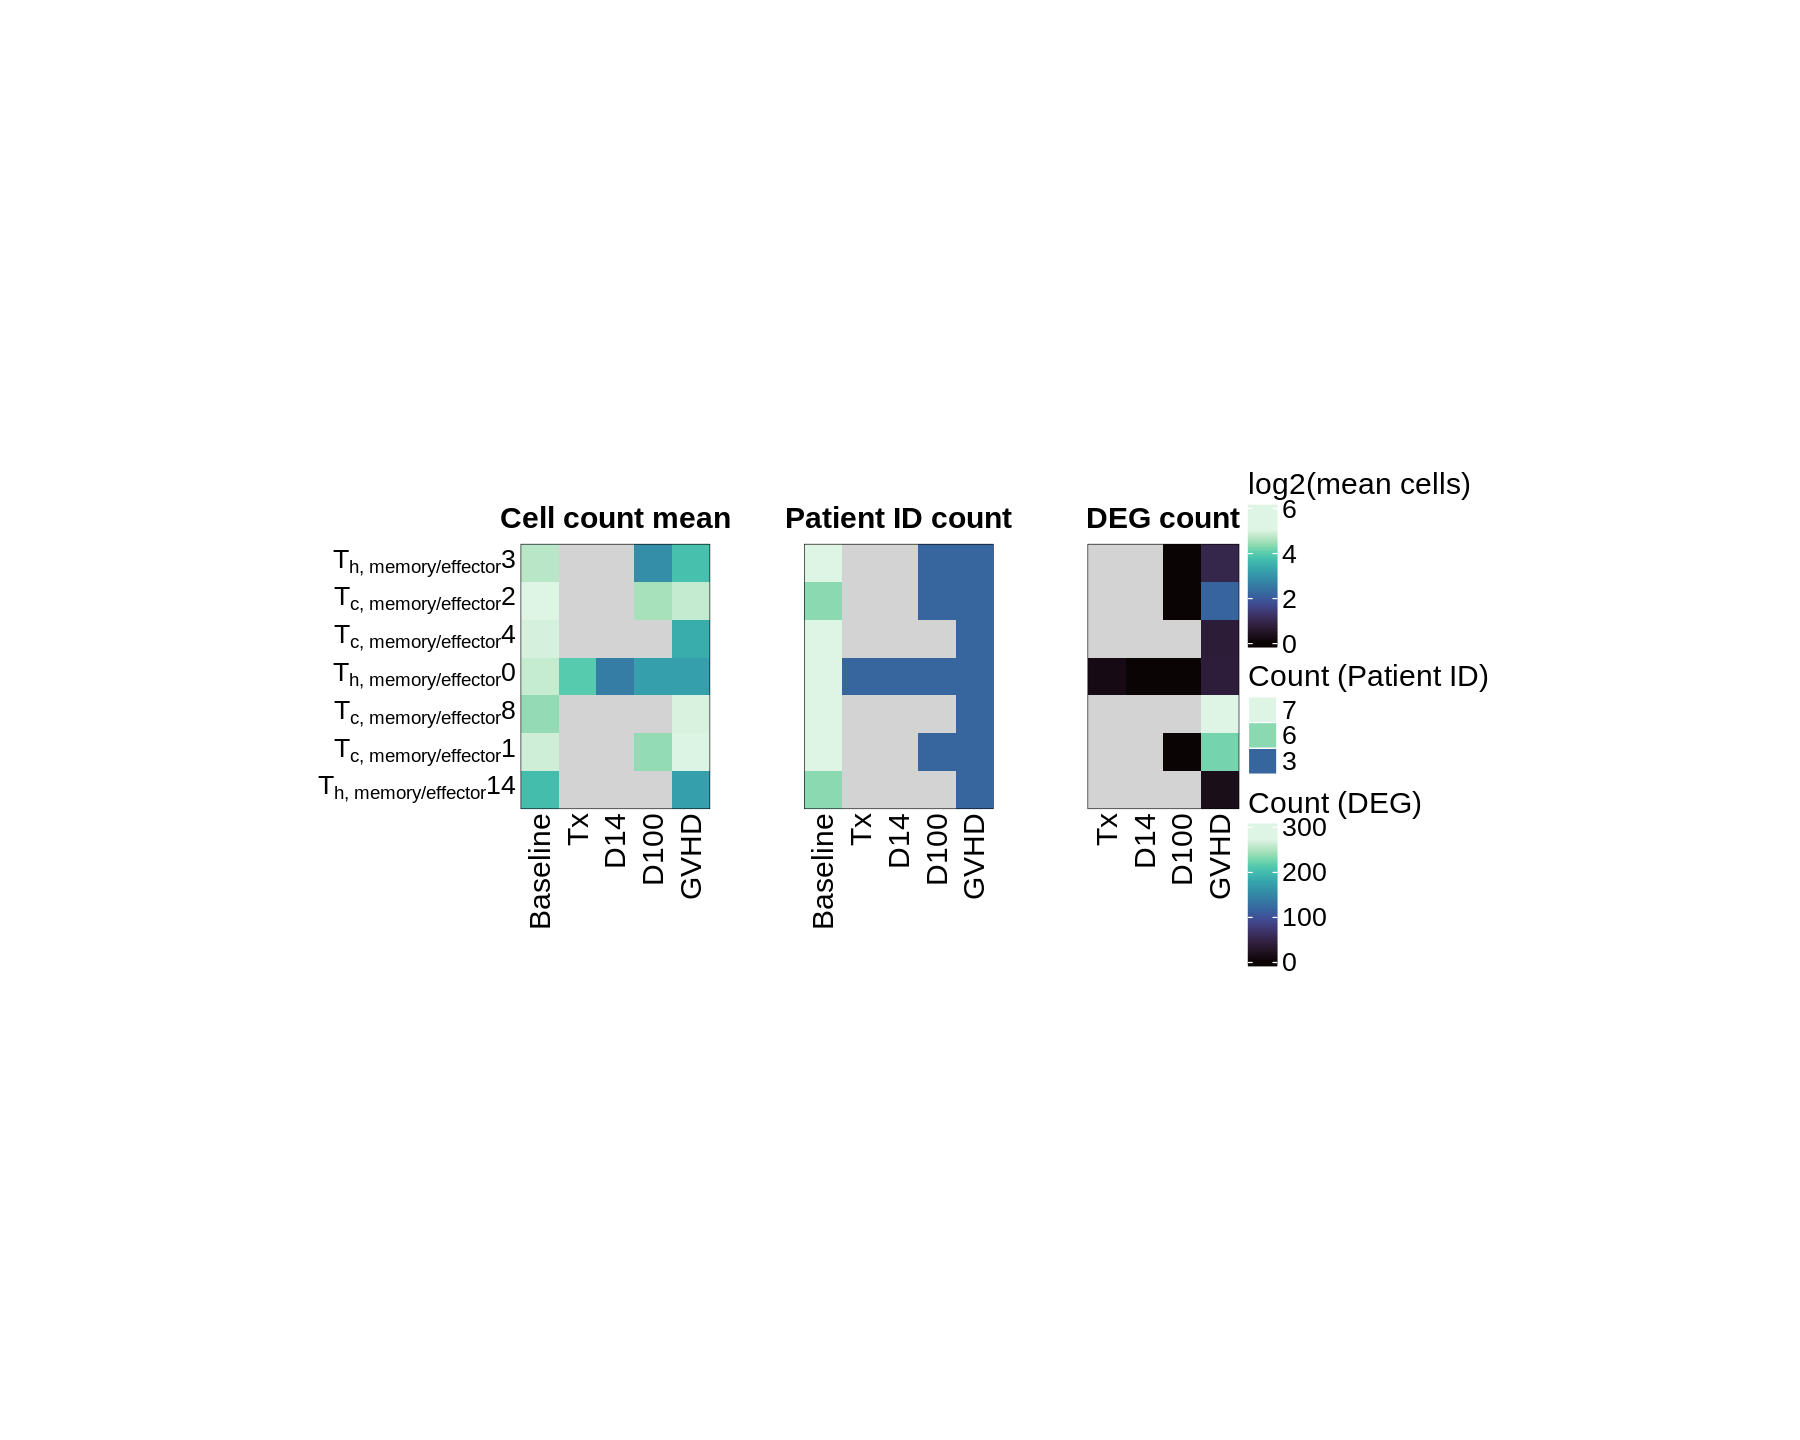

In [32]:
options(repr.plot.width=15, repr.plot.height=12)

draw(hm_1 + hm_2 + hm_3, ht_gap=unit(2, "cm"))

## Volcano plots

In [33]:
results <- results[sapply(results, function(i) length(i)>0)] # Remove empty cell types

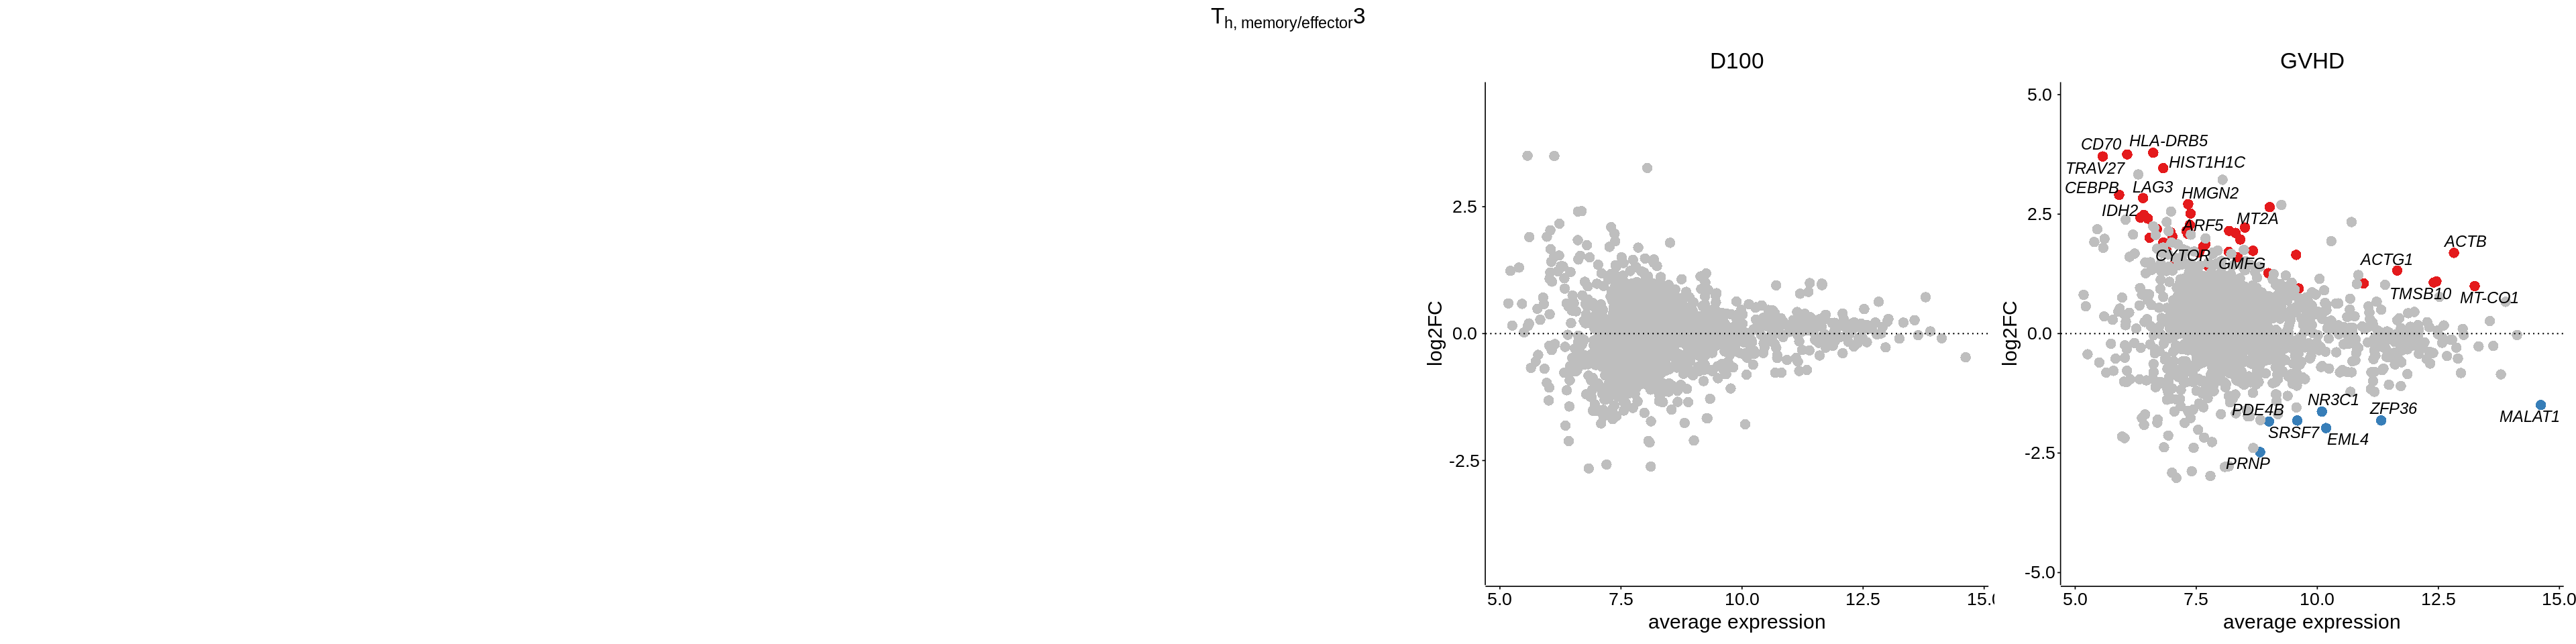

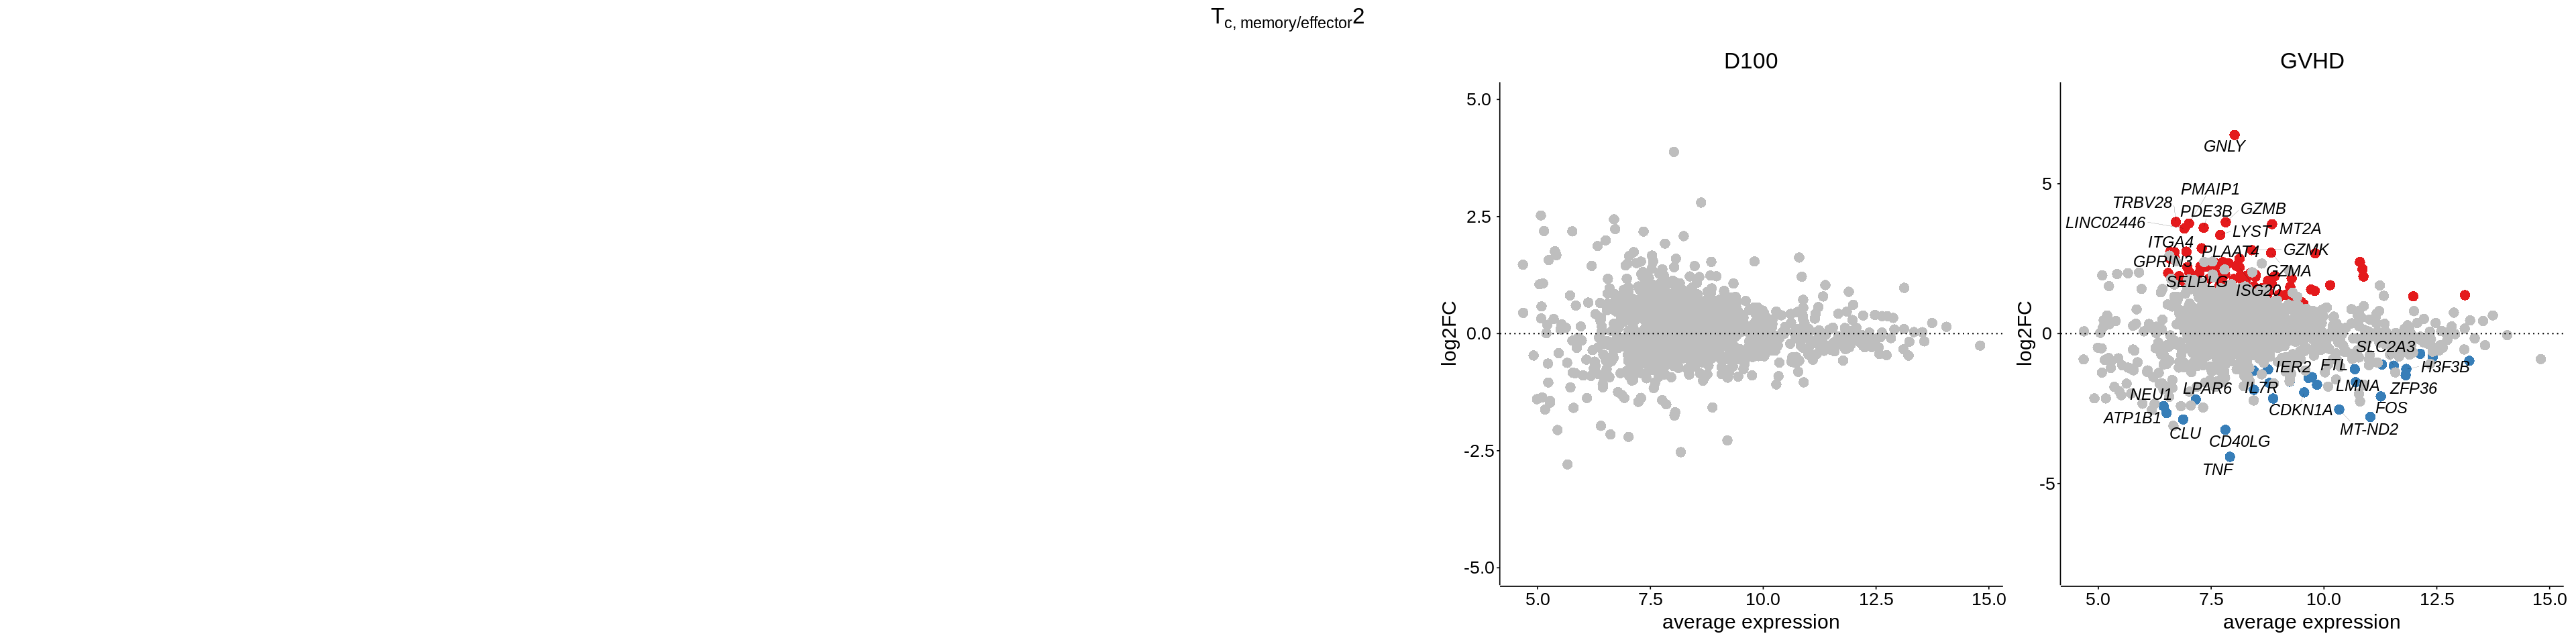

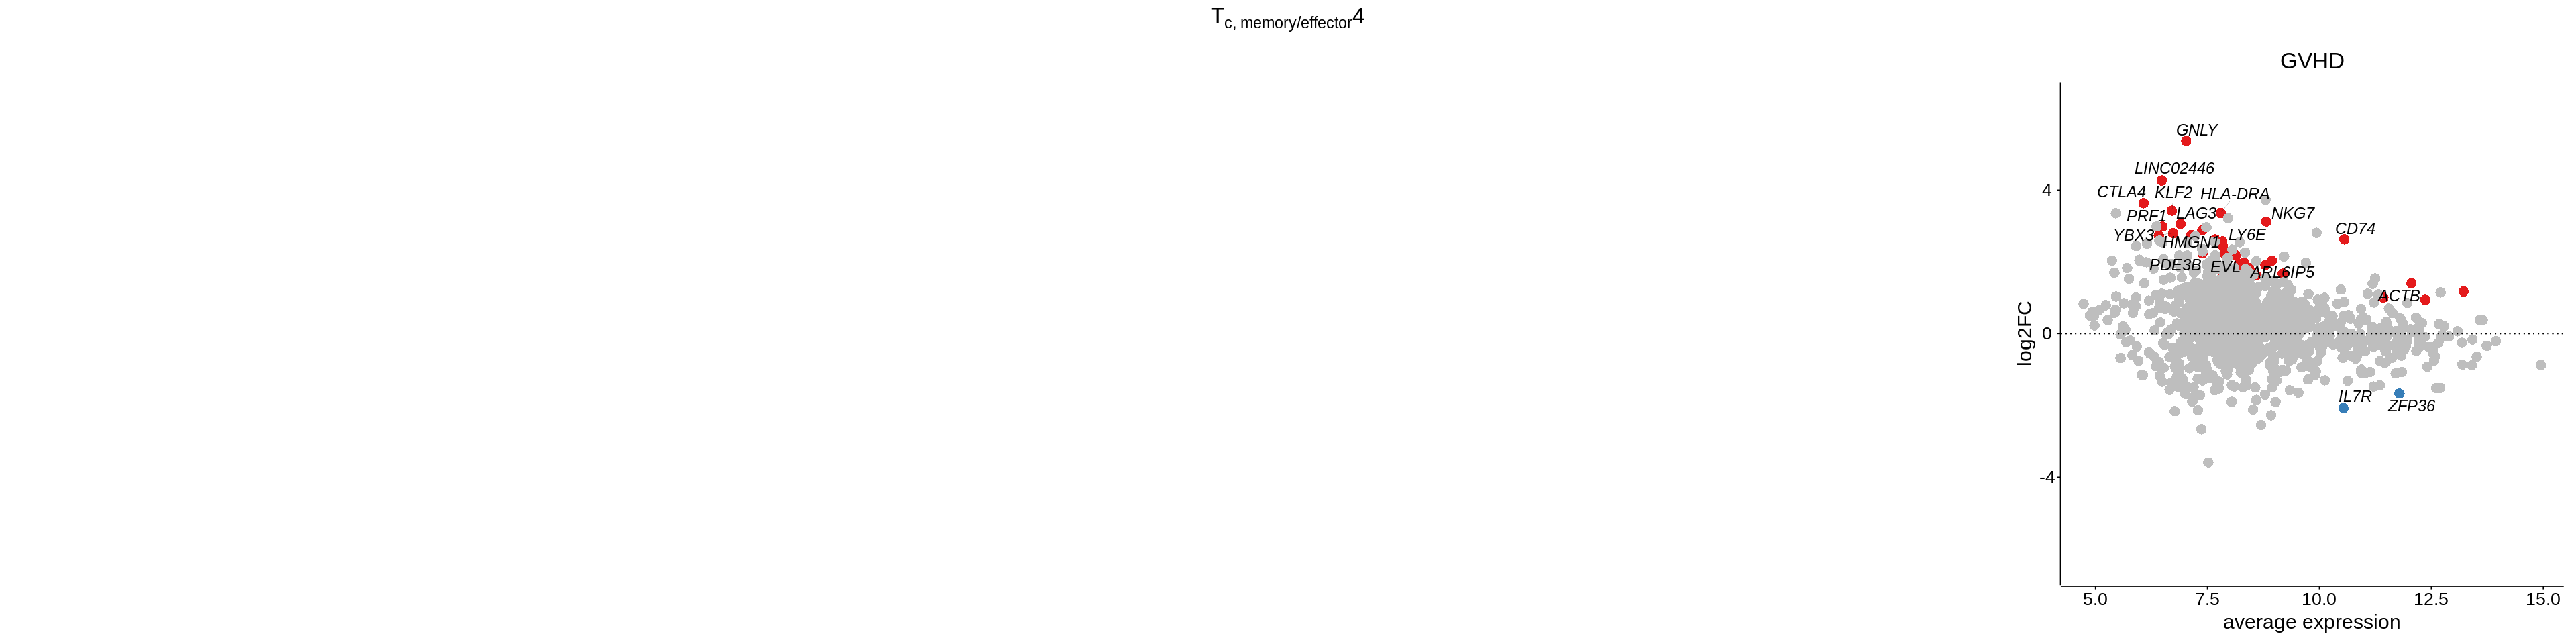

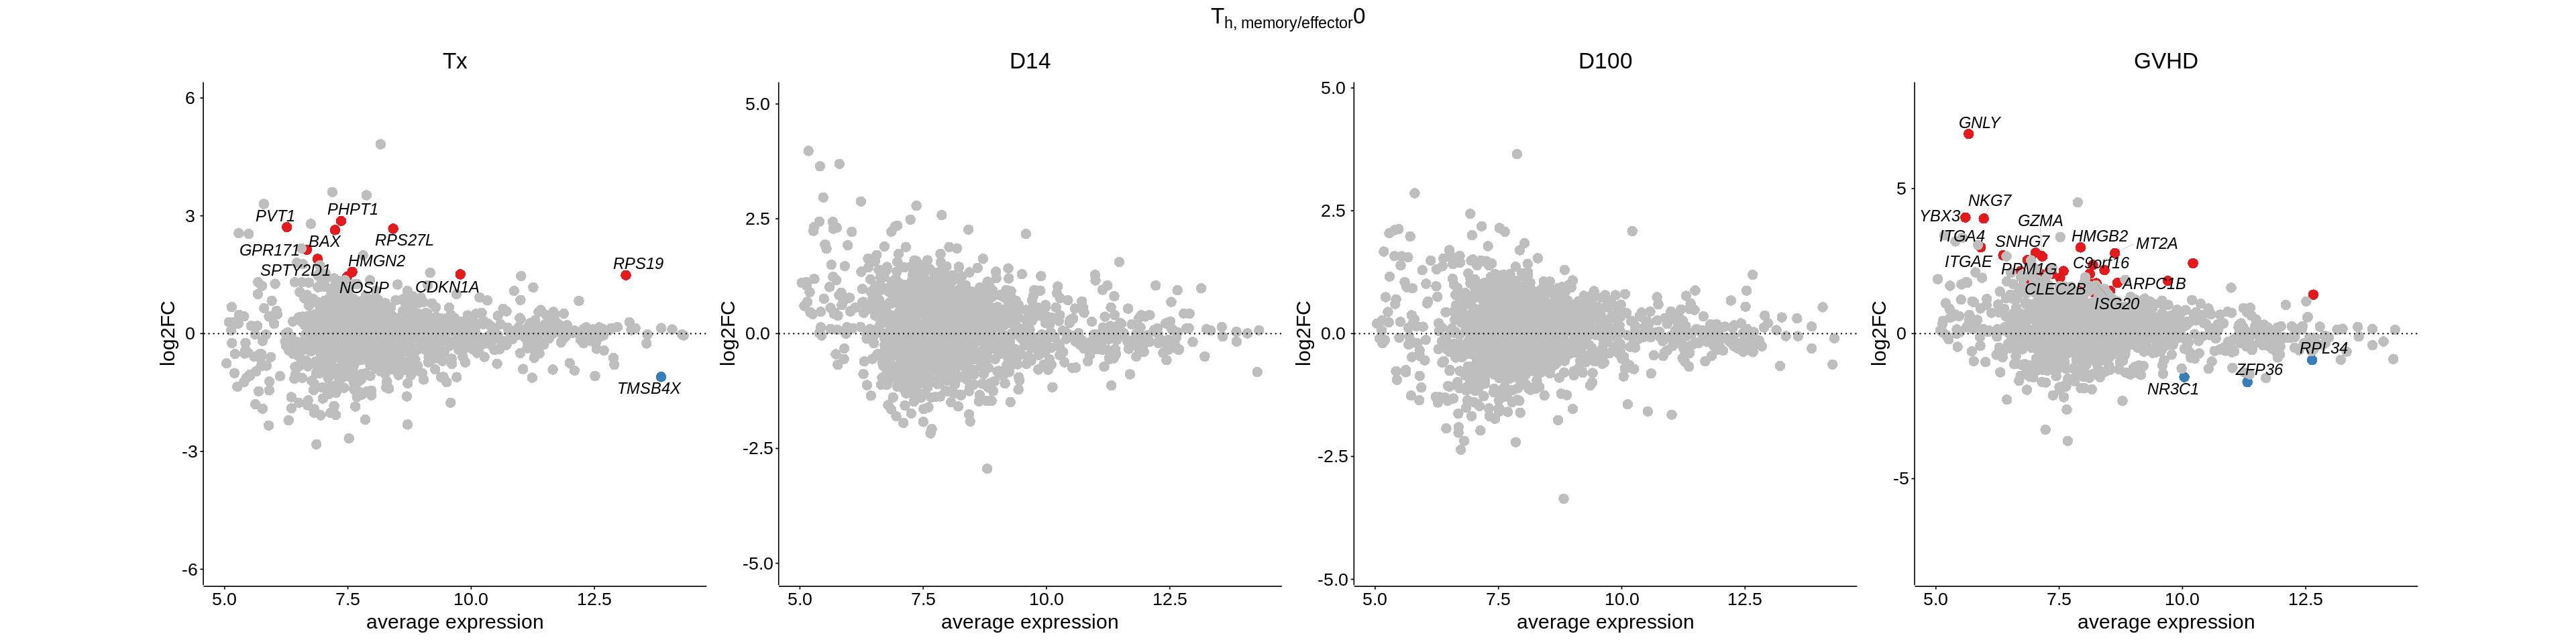

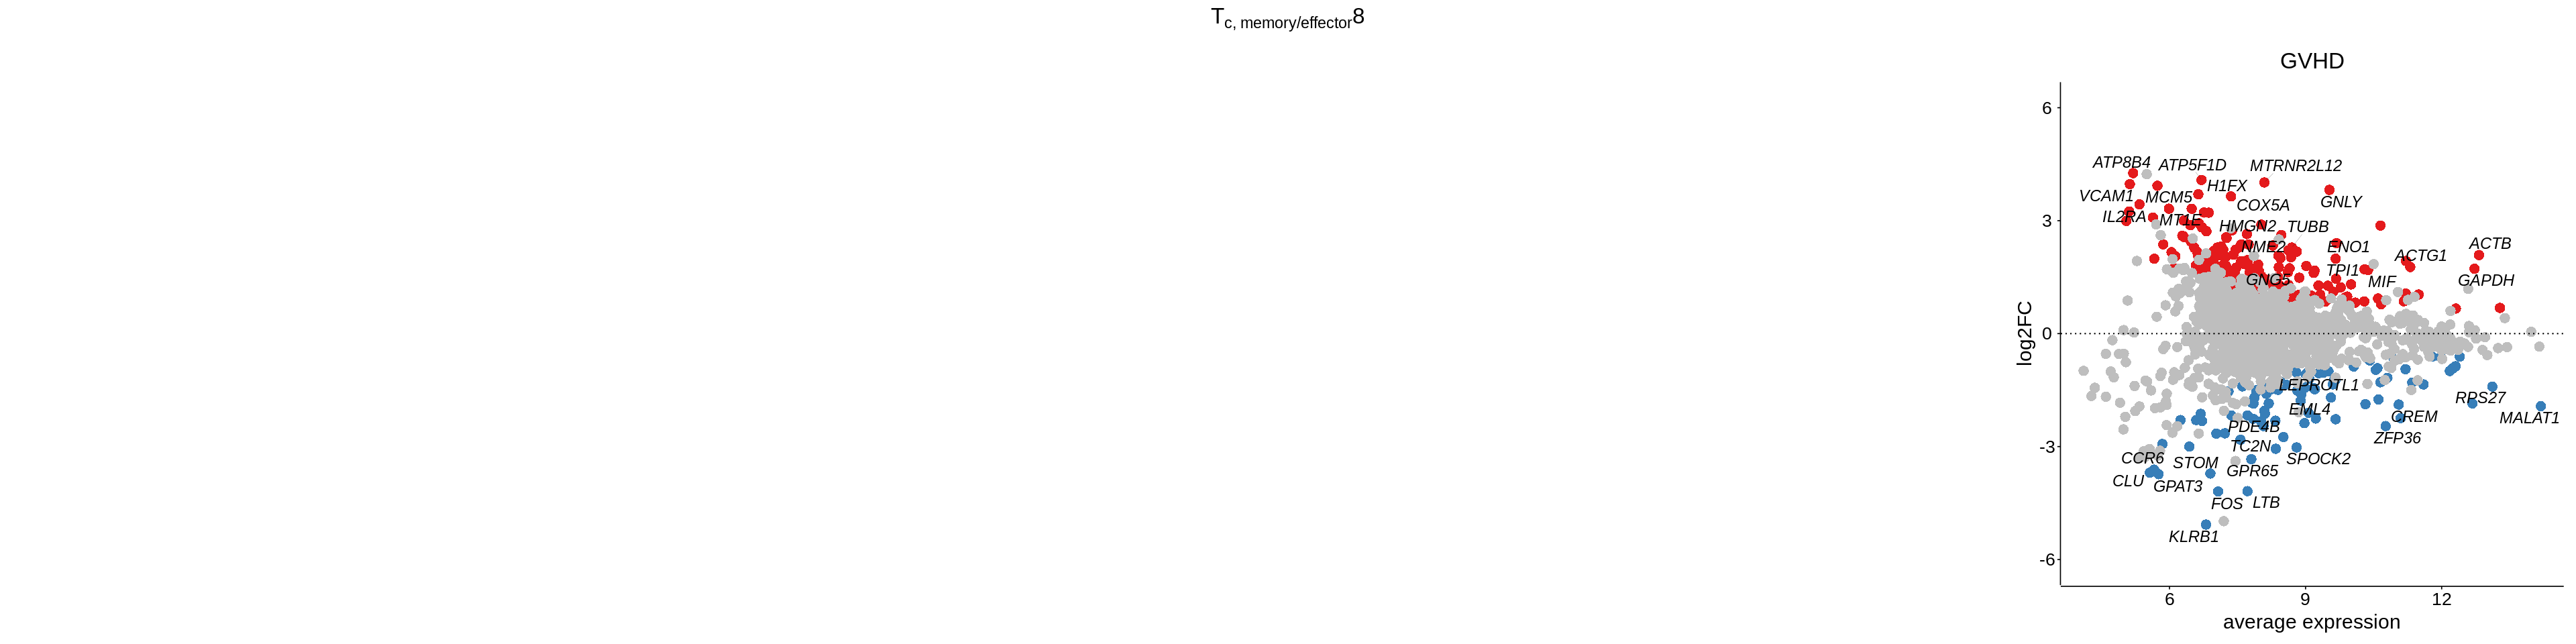

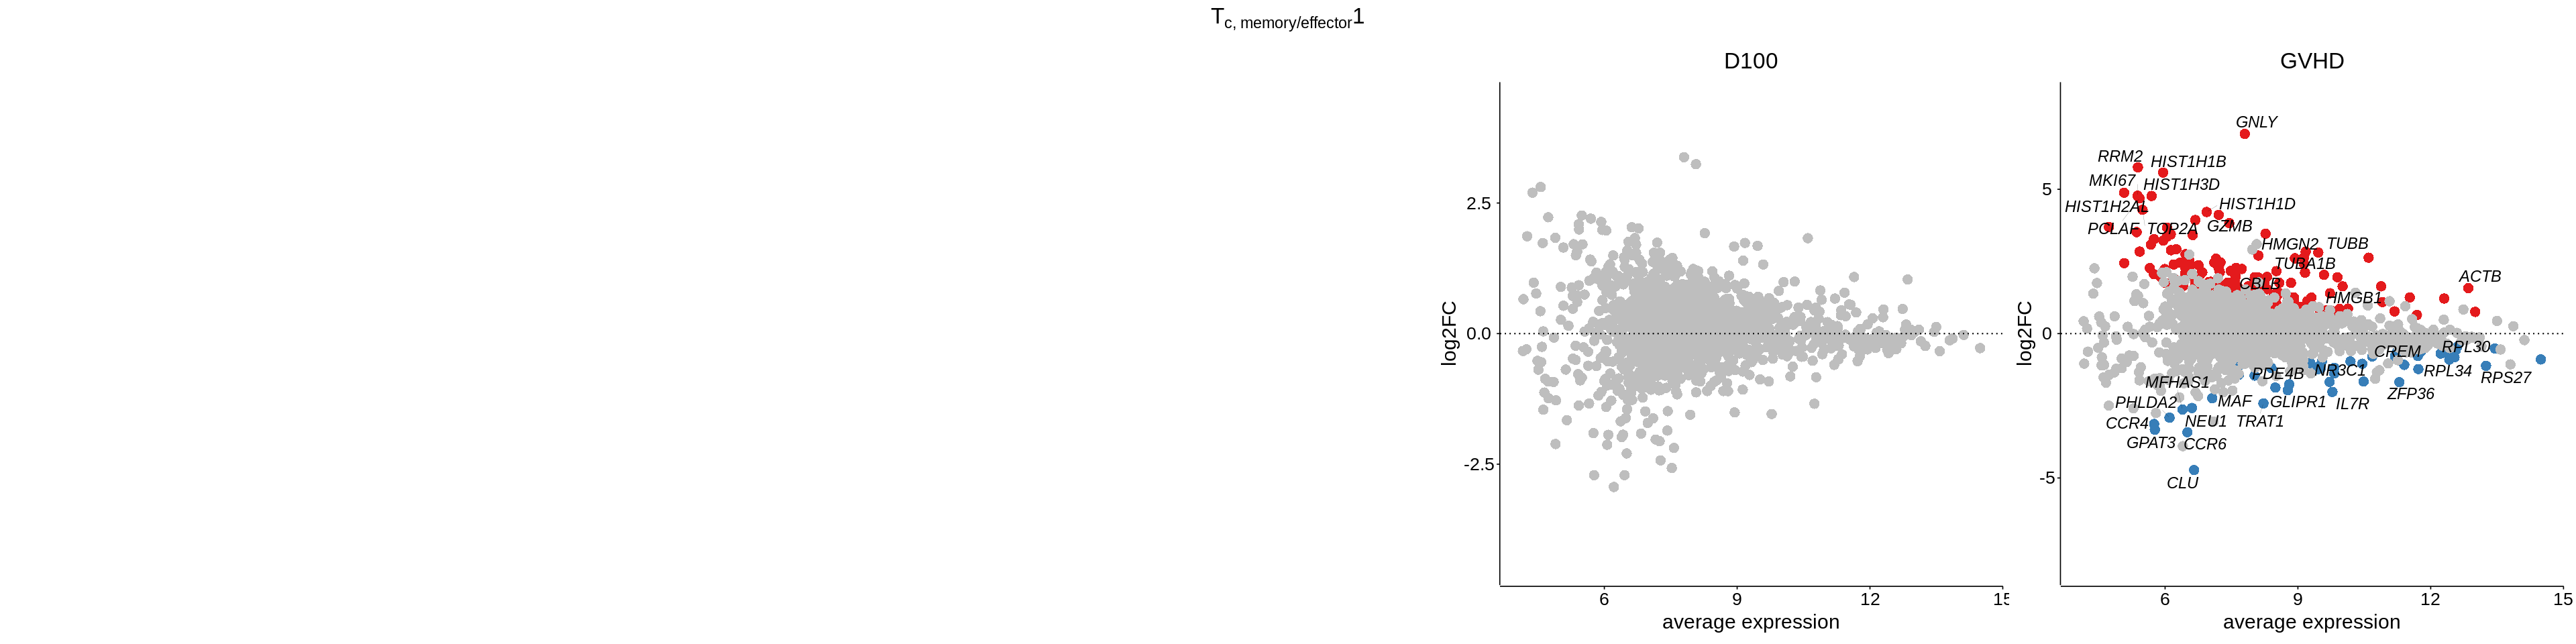

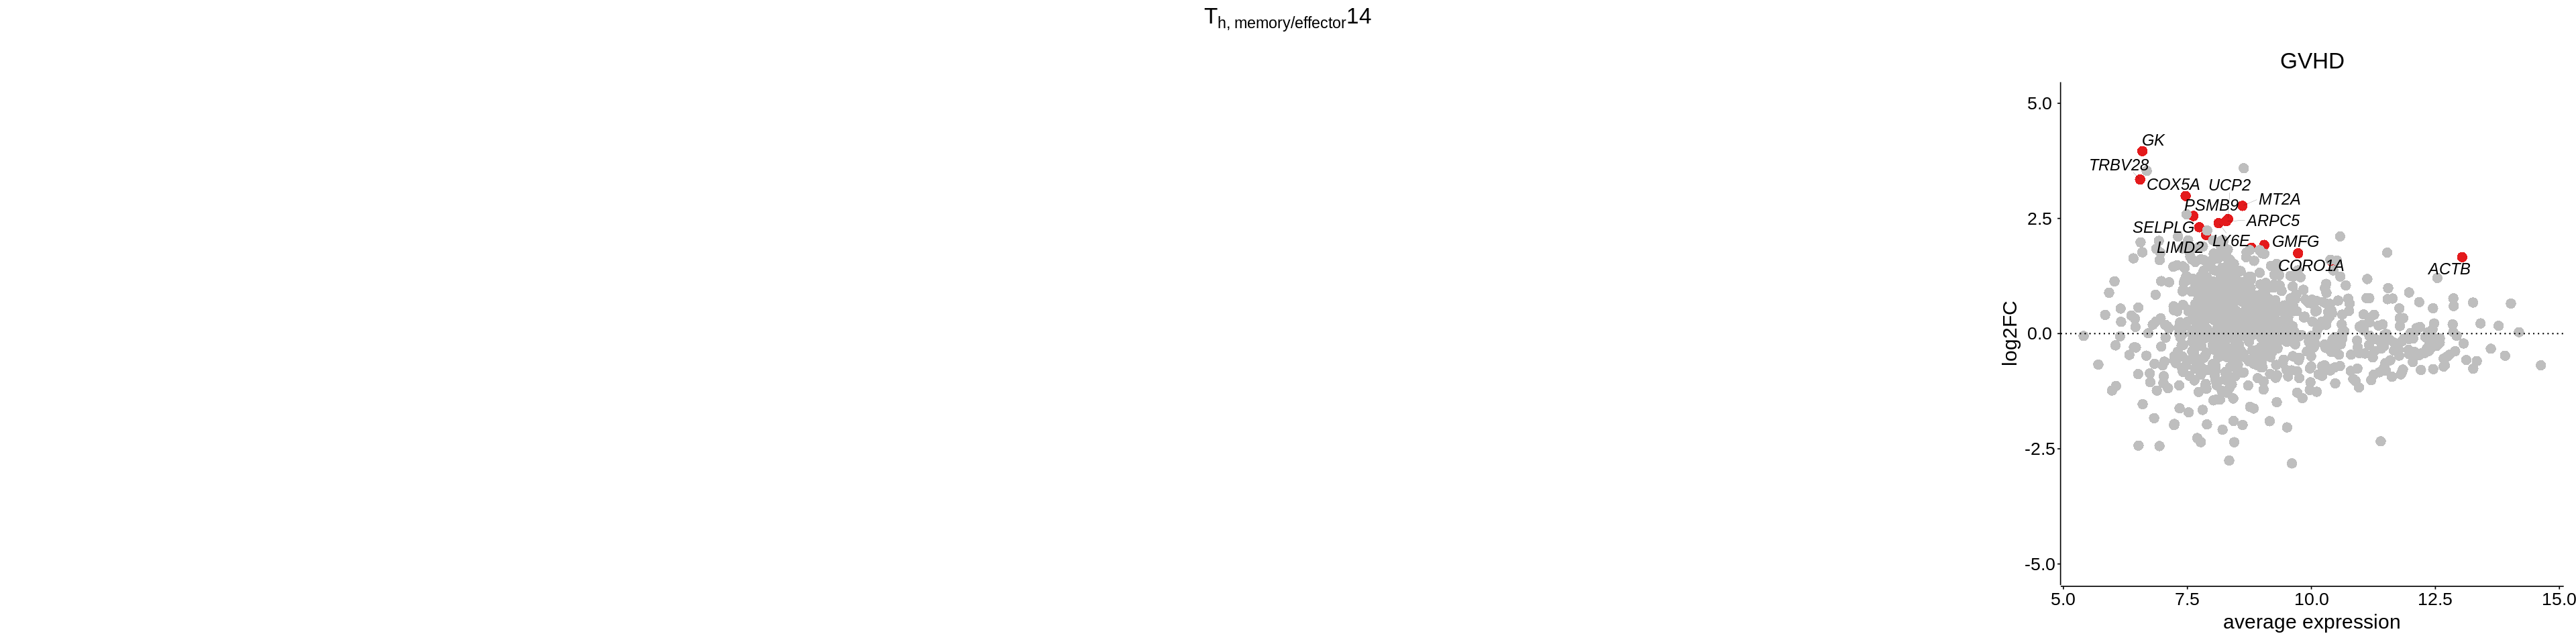

In [34]:
options(repr.plot.width=4*8, repr.plot.height=8)

vp_run(results, p_adj_thr=p_adj_thr)

# Session info

In [35]:
sessionInfo()

R version 4.1.0 (2021-05-18)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.8 (Ootpa)

Matrix products: default
BLAS/LAPACK: /nobackup/peer/fdeckert/miniconda3/envs/r.4.1.0-FD20220623HSCT/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] reticulate_1.31       RColorBrewer_1.1-3    patchwork_1.1.2      
 [4] ggplotify_0.1.0       viridis_0.6.3         viridisLite_0.4.2    
 [7] circlize_0.4.15       ComplexHeatmap_2.10.0 openxlsx_4.2.5.2     
[10] lubridate_1.9.2       forca